In [1]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
import pytest


RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx



[RF-Track] Could not check for updates.


In [2]:
# Bunch parameters
mass = rft.protonmass # MeV/c^2
charge = 1 # single-particle charge, in units of e
population = int(1e12) # number of real particles per bunch
nParticles = int(1e3) # number of macroparticles
En = 12e3 # Total energy [MeV]
Pref = np.sqrt(En**2 - mass**2) # reference momentum, MeV/c
P_Q = Pref / charge # MV/c, reference rigidity

In [3]:
print(Pref)

11963.262326867742


In [4]:
# FODO cell parameters
Lquad = 23.5e-2 # m
Lmag = 194e-2 # m
Ldrift = 2*Lmag # m

Lcell = 2*Lquad+2*Ldrift

mu = np.deg2rad(45) # deg
k1L = np.sin(mu/2) / (Lcell/4) # 1/m

strength = k1L * P_Q # MeV/m

In [5]:
print(strength, k1L)

2225.099533185768 0.18599437782021375


In [6]:
#Half a focusing quadrupole
Qf = rft.Quadrupole(Lquad/2, strength/2)

# A full, defocusing, quadrupole
Qd = rft.Quadrupole(Lquad, -strength)

# The Drift
Dr = rft.Drift(Ldrift)

Define IBS

In [7]:
# Algorithm parameters
dt = 10 # Integration step, mm/c
NT = 16 # Transversal mesh points
NZ = 16 # Longitudinal mesh points
Ncol = 200 # Maximum number of iter.
IBS = rft.IntraBeamScattering(NT, NT, NZ, Ncol)

Define elements for IBS in the same way as usual

In [8]:
#Half a focusing quadrupole
Qf_IBS  = rft.Quadrupole(Lquad/2, strength/2)
Qf_IBS.add_collective_effect(IBS)
Qf_IBS.set_cfx_nsteps(1) # we want to have 10 kicks along the structure

# A full, defocusing, quadrupole
Qd_IBS  = rft.Quadrupole(Lquad, -strength)
Qd_IBS.add_collective_effect(IBS)
Qd_IBS.set_cfx_nsteps(1) # we want to have 10 kicks along the structure

# A full, defocusing, quadrupole
Dr_IBS  = rft.Drift(Ldrift)
Dr_IBS.add_collective_effect(IBS)
Dr_IBS.set_cfx_nsteps(1) # we want to have 10 kicks along the structure

Make FODO for standart and IBS cases

In [9]:
FODO = rft.Lattice()
FODO.append(Qf)
FODO.append(Dr)
FODO.append(Qd)
FODO.append(Dr)
FODO.append(Qf)

L = rft.Lattice()
for _ in range(10):
    L.append(FODO)

In [10]:
FODO_IBS = rft.Lattice()
FODO_IBS.append(Qf_IBS)
FODO_IBS.append(Dr_IBS)
FODO_IBS.append(Qd_IBS)
FODO_IBS.append(Dr_IBS)
FODO_IBS.append(Qf_IBS)

L_IBS = rft.Lattice()
for _ in range(10):
    L_IBS.append(FODO_IBS)

In [11]:
L_IBS.get_length()

82.30000000000003

In [12]:
L_IBS.size()

10

In [13]:
# Define Twiss parameters
Twiss = rft.Bunch6d_twiss()
Twiss.emitt_x = 1*14 # mm.mrad, normalized emittances
Twiss.emitt_y = 1*14 # mm.mrad
Twiss.alpha_x = 0.0
Twiss.alpha_y = 0.0
Twiss.beta_x = Lcell * (1 + np.sin(mu/2)) / np.sin(mu) # m
Twiss.beta_y = Lcell * (1 - np.sin(mu/2)) / np.sin(mu) # m

Pspread = 1.5e-3 # permille, momentum spread
sigma_t = 1 # mm/c
Twiss.sigma_t = sigma_t # mm/c
Twiss.sigma_pt = Pspread # permille

# Create the bunch
B0 = rft.Bunch6d (mass, population, charge, Pref, Twiss, nParticles)

In [14]:
print(Twiss.beta_x)
print(Twiss.beta_y)

16.093021522533775
7.1849337141273715


Perform tracking

In [15]:
%%time
B1 = L.track(B0)

CPU times: user 47.7 ms, sys: 106 ms, total: 154 ms
Wall time: 95.3 ms


In [16]:
I = B1.get_info()
E_after_ibs = I.sigma_E
F_ibs = IBS.compute_force(B0, dt)[0]

TypeError: Wrong number or type of arguments for overloaded function 'IntraBeamScattering_compute_force'.
  Possible C/C++ prototypes are:
    IntraBeamScattering::compute_force(MatrixNd &,Bunch6d const &,double,double,ParticleSelector const &)
    IntraBeamScattering::compute_force(MatrixNd &,Bunch6d const &,double,double)
    IntraBeamScattering::compute_force(MatrixNd &,Bunch6dT const &,double)


In [17]:
%%time
B1_IBS = L_IBS.track(B0)

CPU times: user 3.02 s, sys: 1.29 s, total: 4.31 s
Wall time: 1.31 s


In [18]:
T = L.get_transport_table('%S %beta_x %beta_y %emitt_x %emitt_y %sigma_x %sigma_y');
T_IBS = L_IBS.get_transport_table('%S %beta_x %beta_y %emitt_x %emitt_y %sigma_x %sigma_y');

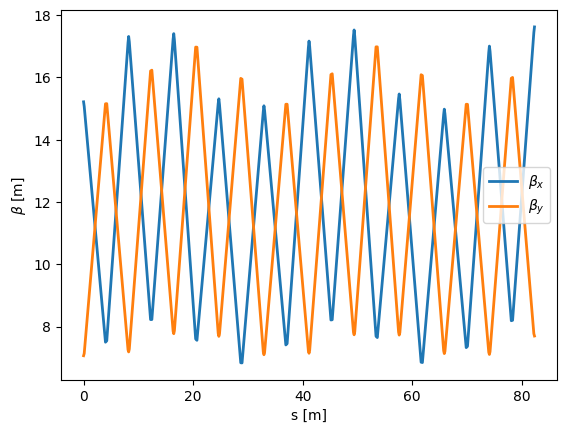

In [19]:
plt.plot(T[:,0], T[:,1], linewidth=2, label=r'$\beta_x$')
plt.plot(T[:,0], T[:,2], linewidth=2, label=r'$\beta_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.show()

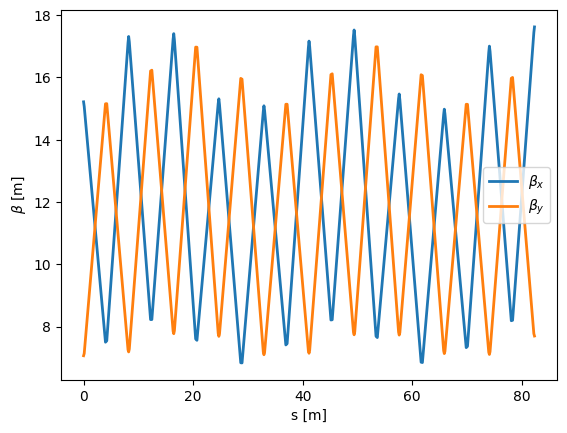

In [20]:
plt.plot(T_IBS[:,0], T_IBS[:,1], linewidth=2, label=r'$\beta_x$')
plt.plot(T_IBS[:,0], T_IBS[:,2], linewidth=2, label=r'$\beta_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.show()

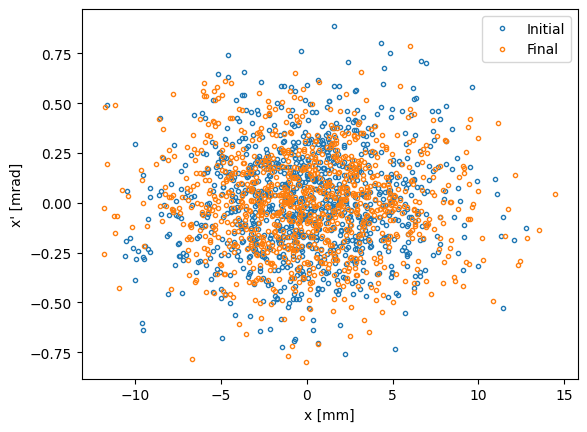

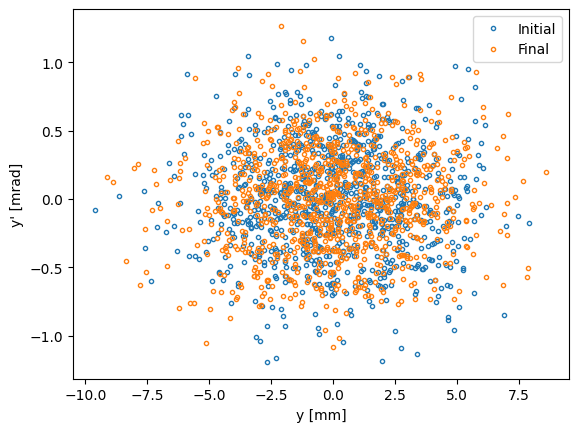

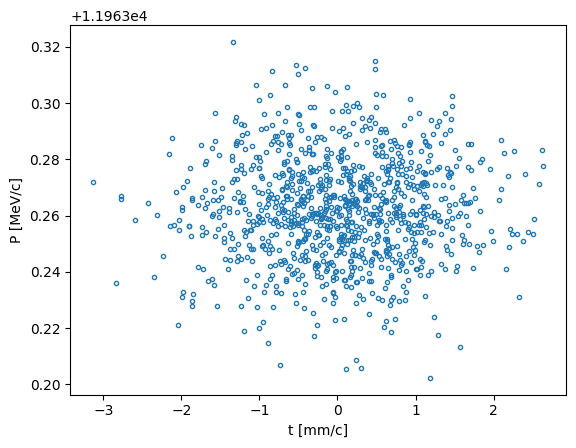

In [21]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B1_IBS.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()

plt.figure()
plt.plot(M1[:,4], M1[:,5], '.', label='Final', mfc='none')
plt.xlabel('t [mm/c]')
plt.ylabel('P [MeV/c]')
plt.show()

In [22]:
T = L.get_transport_table('%S %emitt_x %emitt_y')
T_IBS = L_IBS.get_transport_table('%S %emitt_x %emitt_y')

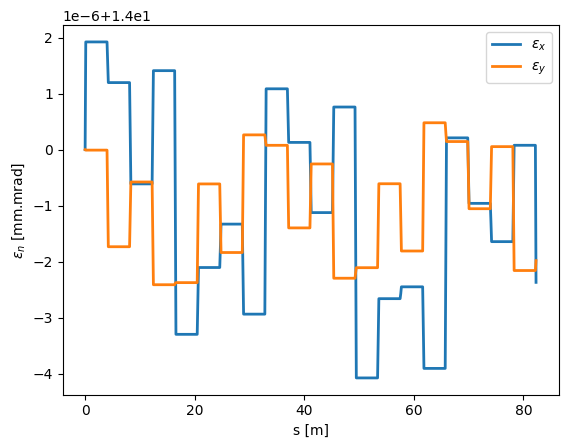

In [23]:
plt.plot(T[:,0], T[:,1], linewidth=2, label=r'$\epsilon_x$')
plt.plot(T[:,0], T[:,2], linewidth=2, label=r'$\epsilon_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

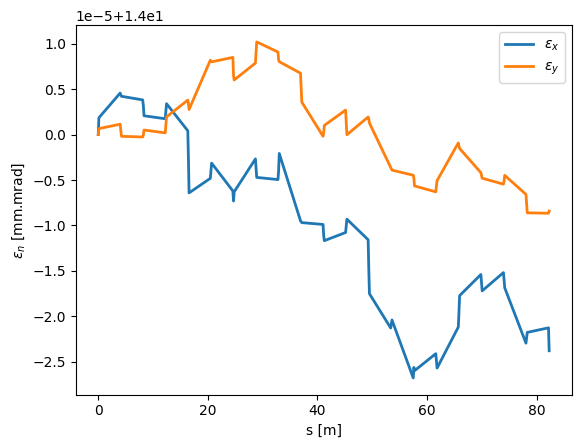

In [24]:
plt.plot(T_IBS[:,0], T_IBS[:,1], linewidth=2, label=r'$\epsilon_x$')
plt.plot(T_IBS[:,0], T_IBS[:,2], linewidth=2, label=r'$\epsilon_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

In [25]:
# function for tracking in lattice over several turns
def multiturn_track(closed_lattice, initial_bunch, N_turns):
    
    current_bunch = initial_bunch
    
    data_collector = [] # for bunch parameters over turn
    
    for turn_num in range(N_turns):
        final_bunch = closed_lattice.track(current_bunch)
        current_bunch = final_bunch
        #print(f'Turn: {_} complete') 

        I = final_bunch.get_info()

        #save bunch parmeters after each turn
        current_row = [
            turn_num + 1,  # turn number
            I.mean_K,
            I.emitt_x,
            I.emitt_y,
            I.emitt_6d
        ]

        #collect data 
        data_collector.append(current_row)
        # print(f'Turn: {turn_num + 1} complete. Emitt_x: {I.emitt_x:.2e}')

    #convert
    beam_parameters_array = np.array(data_collector)
    return final_bunch, beam_parameters_array

In [26]:
%%time
B_final, bunch_data = multiturn_track(L, B0, 10)

CPU times: user 293 ms, sys: 1.12 s, total: 1.42 s
Wall time: 877 ms


In [27]:
%%time
B_final_IBS, bunch_data_IBS = multiturn_track(L_IBS, B0, 10)

CPU times: user 31.2 s, sys: 13.4 s, total: 44.6 s
Wall time: 14 s


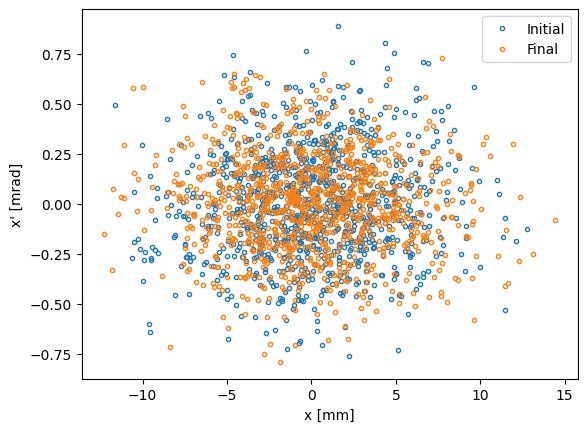

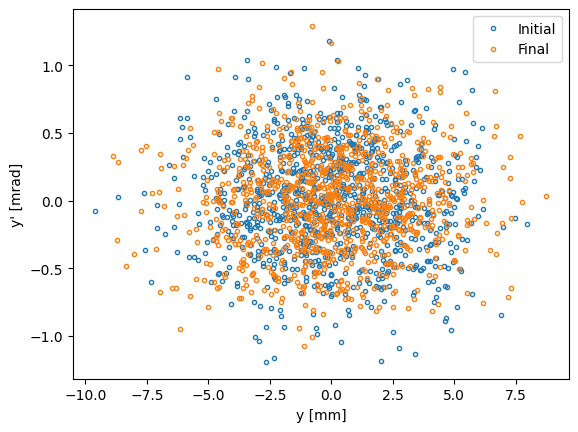

In [28]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B_final.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()
plt.show()

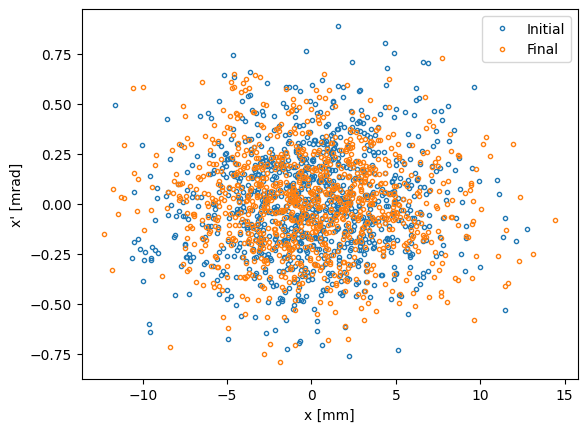

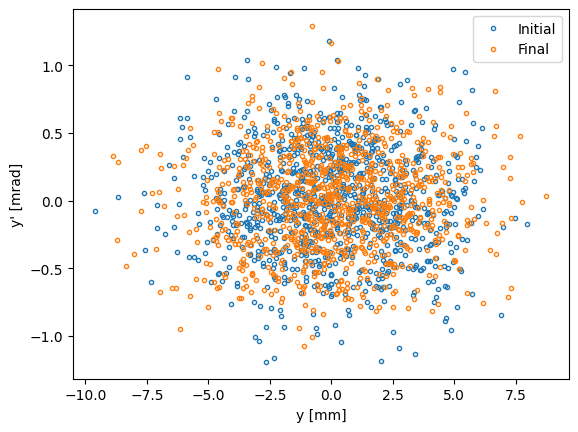

In [29]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B_final_IBS.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()
plt.show()

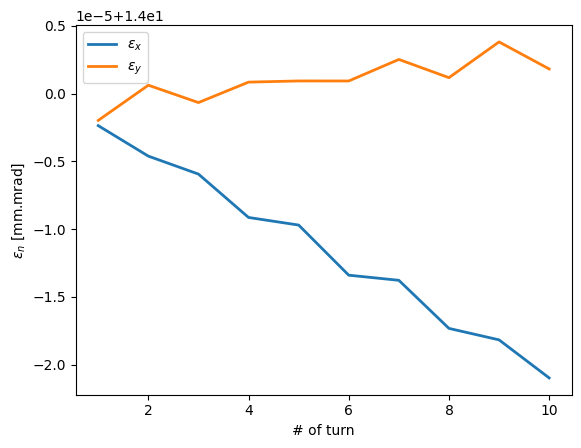

In [30]:
plt.plot(bunch_data[:,0], bunch_data[:,2], linewidth=2, label=r'$\epsilon_x$')
plt.plot(bunch_data[:,0], bunch_data[:,3], linewidth=2, label=r'$\epsilon_y$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

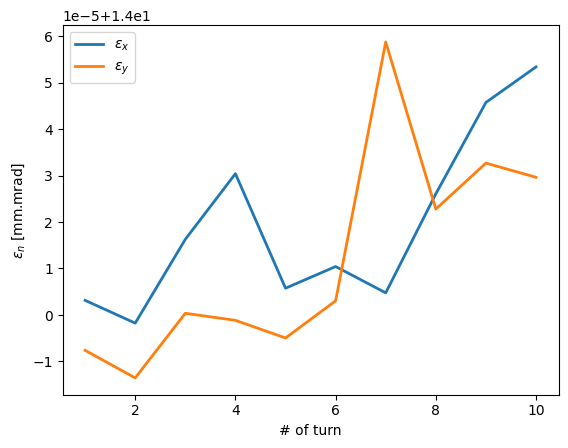

In [31]:
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,2], linewidth=2, label=r'$\epsilon_x$')
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,3], linewidth=2, label=r'$\epsilon_y$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()